# Using conjugate gradient to experiment with things 

## TODO: look at why linearization of J^J at initialization works remarkably well for some reason. Can we try something? 

## Basic import and setup

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
# For viz
import treescope
treescope.basic_interactive_setup(
    autovisualize_arrays=True,
    abbreviation_threshold=2, 
)
treescope.register_as_default()


## Model Definition 

We use a 1D for now; we don't do the sow stuff as we're testing the conjugate gradient and basic preconditioners rather than the ASM stuff for now. 

In [2]:
# Create standard model
class MLP_1D(nn.Module):
    num_layers: int = 2
    hidden_dim: int = 6

    @nn.compact
    def __call__(self, x):
        # Input x is expected to be of shape (batch_size, 1)
        for _ in range(self.num_layers):
            x = nn.Dense(
                features=self.hidden_dim, use_bias=True,
                kernel_init=nn.initializers.kaiming_uniform(),  # Kaiming uniform initialization
                bias_init=nn.initializers.zeros  # Bias initialized to zero
            )(x)
            x = nn.tanh(x)  # Apply activation function after each layer
        x = nn.Dense(features=1)(x)
        return x


## Constant and Data Generation 

We generate 1D data without noise and set some constants regarding the model which is uniform among all the tests such as layers and dimensions. 


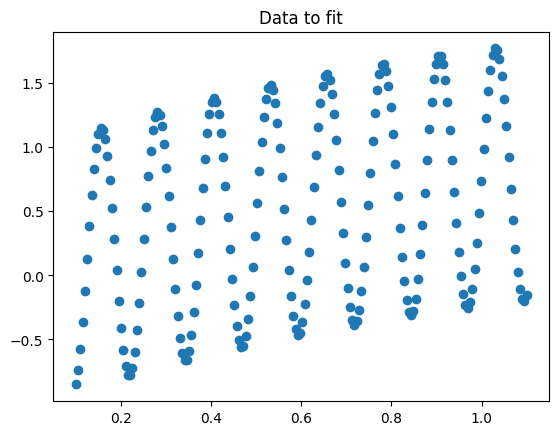

In [15]:
# Model definition 
L = 8
n = 16 

num_samples = 200
# X = jax.random.uniform(jax.random.PRNGKey(0), (num_samples, 1), minval=0, maxval=1)
X = jnp.linspace(0, 1, num_samples).reshape((-1, 1)) + .1
y = jnp.sin(16 * jnp.pi * X) + jnp.tanh(X)

plt.scatter(X, y)
plt.title('Data to fit')
plt.show()
# zeros_to_append = jnp.zeros((num_samples, n-1))

# # Concatenate the original array and the zeros array along axis 1 (columns)
# X = jnp.concatenate((X, zeros_to_append), axis=1)
# y = jnp.concatenate((y, zeros_to_append), axis=1)
# treescope.display((X, y))



## First, train using standard 

We just use SGD/Adam. This way, we have a baseline for at least baseline performance of the algorithms. 

In [ ]:
def train_model_sgd(X_train, y_train, model, params, learning_rate, num_epochs):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

    @jax.jit
    def train_step(state, batch_X, batch_y):
        """
        We use full batch
        """
        def loss_fn(params):
            predictions = state.apply_fn({'params': params}, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions - batch_y))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn(state.params)
        state = state.apply_gradients(grads=grads)
        return state, loss

    losses = []
    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        state, loss = train_step(state, X_train, y_train)
        losses.append(loss)

    return state, losses

num_epochs = 50_000

key = jax.random.PRNGKey(0)

model = MLP_1D(num_layers=L, hidden_dim=n)
params = model.init(key, jnp.ones((1, 1)))['params']

# Train the model
trained_state_sgd, sgd_losses = train_model_sgd(
    X, y, model, params, learning_rate=2e-3, num_epochs=num_epochs
)

In [ ]:
predicted_y = model.apply({'params': trained_state_sgd.params}, X)

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# First subplot for True vs. Predicted Data
plt.subplot(1, 2, 1)  # 2 rows, 1 column, 1st subplot
plt.scatter(X, y, marker='o', label='True Data', alpha=0.5)
plt.scatter(X, predicted_y, marker='x', color='red', label='Predicted Data', alpha=0.6)
plt.title('1D Regression Problem: True vs. Predicted Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Second subplot for Training Loss over Epochs
plt.subplot(1, 2, 2)  # 2 rows, 1 column, 2nd subplot
plt.semilogy(sgd_losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)

# Show the combined plot
plt.tight_layout()  
plt.show()

## No GD

In [68]:
def train_model_precond(X_train, y_train, model, params, learning_rate, num_epochs,
                       lamb=1e-1):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)
    
    @jax.jit
    def train_step(state, batch_X, batch_y):
        """
        We use full batch
        """
        @jax.jit
        def loss_fn(params):
            predictions = state.apply_fn({'params': params}, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions - batch_y))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn(state.params)

        # Explicitly construct Jacobian 
        jacobian = jax.jacobian(state.apply_fn, argnums=0)({'params': state.params}, X)
        flattened, _ = jax.tree.flatten(jacobian)
        reshaped_leaves = [leaf.reshape(batch_X.shape[0], -1) for leaf in flattened]
        aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
        jacobian = aggregated_array.reshape((batch_X.shape[0], -1))

        # Explicitly construct the Jacobian
        # jacobian_fn = jax.jacrev(state.apply_fn)({'params': params}, X)
        # flat_jacobian = []
        # for layer in jacobian_fn['params'].values():
        #     for dense in layer.values():  # This is specific for the above architecture... not very extendable yet
        #         for param in dense.values(): 
        #             flat_jacobian.append(
        #                 param.reshape((batch_X.shape[0] * batch_X.shape[1], -1))
        #             )
        #     # jacobian_fn
        # jacobian = jnp.concatenate(flat_jacobian, axis=1)

        jtj = jacobian.T @ jacobian

        lm_mat = lamb * jnp.eye(jtj.shape[0]) + jtj
        flattened, back = jax.flatten_util.ravel_pytree(grads)
        altered = jnp.linalg.solve(lm_mat, flattened) # Solve directly 
        grads = back(altered) # Convert vector back to PyTree

        # jax.debug.print('grads={altered}', altered=altered)
        state = state.apply_gradients(grads=grads)
        return state, loss

    losses = []
    cg_stats = {
        'resids': [], 'iters': []
    }

    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        state, loss = train_step(state, X_train, y_train)
        if loss > 1e2:
            break
        losses.append(loss)
    return state, losses

# num_epochs = 50_000
num_epochs = 10_000

key = jax.random.PRNGKey(0)

model = MLP_1D(num_layers=L, hidden_dim=n)
params = model.init(key, jnp.ones((1, 1)))['params']

# Train the model
trained_state_precond, precond_losses = train_model_precond(
    X, y, model, params, learning_rate=5e-3, num_epochs=num_epochs
)
# trained_state_precond, precond_losses = train_model_precond(
#     X, y, model, params, learning_rate=5e-3, num_epochs=num_epochs
# )

Starting training for 10000 epochs...


  0%|          | 0/10000 [00:00<?, ?it/s]

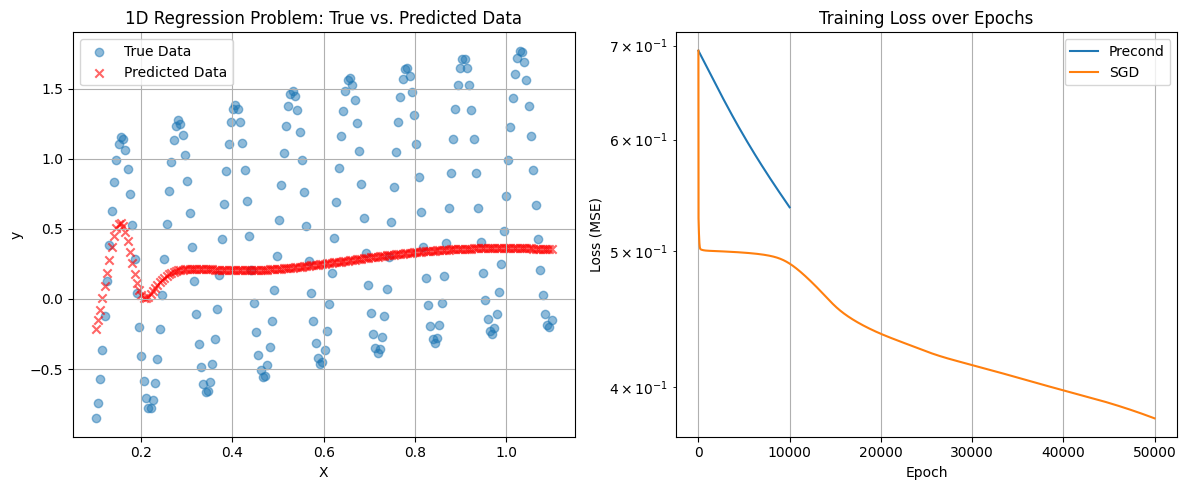

In [69]:
predicted_y = model.apply({'params': trained_state_precond.params}, X)

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# First subplot for True vs. Predicted Data
plt.subplot(1, 2, 1)  # 2 rows, 1 column, 1st subplot
plt.scatter(X, y, marker='o', label='True Data', alpha=0.5)
plt.scatter(X, predicted_y, marker='x', color='red', label='Predicted Data', alpha=0.6)
plt.title('1D Regression Problem: True vs. Predicted Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Second subplot for Training Loss over Epochs
plt.subplot(1, 2, 2)  # 2 rows, 1 column, 2nd subplot
plt.semilogy(precond_losses, label='Precond')
plt.semilogy(sgd_losses, label='SGD')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Show the combined plot
plt.tight_layout()  
plt.show()


## Use conjugate gradient to do precond GD 

In [62]:
@jax.jit
def tree_dot(a, b):
    return jax.tree.reduce(
        lambda x, y: x + y,
        jax.tree.map(lambda x, y: jnp.vdot(x, y), a, b)
    )


def conjugate_gradient(matvec, b, state, x, tol=1e-5, max_iter=1000):
    def body_fn(carry):
        k, r, p, rsold, i = carry
        Ap = matvec(p)
        alpha = rsold / tree_dot(p, Ap)
        k = jax.tree.map(lambda k, p: k + alpha * p, k, p)
        r = jax.tree.map(lambda r, Ap: r - alpha * Ap, r, Ap)
        rsnew = tree_dot(r, r)
        p = jax.tree.map(lambda r, p: r + (rsnew / rsold) * p, r, p)
        return k, r, p, rsnew, i + 1

    def cond_fn(carry):
        _, _, _, rsnew, i = carry
        return jnp.logical_and(jnp.sqrt(rsnew) >= tol, i < max_iter)

    k = jax.tree.map(jnp.zeros_like, b)  # Initial guess k = 0
    r = jax.tree.map(lambda x: x, b)  # Initial residual r = b - A * k (A * k = 0 initially)
    p = jax.tree.map(lambda x: x, r)  # Initial direction p = r
    rsold = tree_dot(r, r)

    init_carry = (k, r, p, rsold, 0)
    k, r, p, rsnew, i = jax.lax.while_loop(cond_fn, body_fn, init_carry)

    return k, (jnp.sqrt(rsnew), i)


In [65]:
def train_model_precond_cg(X_train, y_train, model, params, learning_rate, num_epochs,
                          lamb=1e-1):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)
    
    @jax.jit
    def train_step(state, batch_X, batch_y):
        """
        We use full batch
        """
        @jax.jit
        def loss_fn(params):
            predictions = state.apply_fn({'params': params}, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions - batch_y))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn(state.params)

        # Conjugate gradient
        # TODO: figure out why 
        # _, f_jvp = jax.linearize(lambda p: 
                                 # state.apply_fn({'params': params}, batch_X), state.params)
        # worked so well? 
        _, f_jvp = jax.linearize(lambda p: 
                                 state.apply_fn({'params': p}, batch_X), 
                                 state.params)
        f_vjp = jax.linear_transpose(f_jvp, state.params)
        
        @jax.jit
        def matvec(k):
            Av = f_vjp(f_jvp(k))[0]
            # Add the regularization term lambda * k
            Av = jax.tree_util.tree_map(lambda a, b: a + lamb * b, Av, k)
            return Av

        grads_cg, lm_data = conjugate_gradient(
            matvec, grads, state, batch_X, max_iter=1000,tol=1e-8
        )

        # We can verify that they're equal by explicitly constructing matrices 
        # Explicitly construct Jacobian 
        # jacobian = jax.jacobian(state.apply_fn, argnums=0)({'params': params}, X)
        # flattened, _ = jax.tree.flatten(jacobian)
        # reshaped_leaves = [leaf.reshape(batch_X.shape[0], -1) for leaf in flattened]
        # aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
        # jacobian = aggregated_array.reshape((batch_X.shape[0], -1))
        # jtj = jacobian.T @ jacobian

        # lm_mat = lamb * jnp.eye(jtj.shape[0]) + jtj
        # flattened, back = jax.flatten_util.ravel_pytree(grads)
        # altered = jnp.linalg.solve(lm_mat, flattened) # Solve directly 
        # grads_mat = back(altered) # Convert vector back to PyTree
        
        # l2_norm_diff = jnp.sqrt(sum(jnp.sum((a - b)**2) for a, b in zip(jax.tree_leaves(grads_cg), jax.tree_leaves(grads_mat))))
        # l2_norm_grads_mat = jnp.sqrt(sum(jnp.sum(b**2) for b in jax.tree_leaves(grads_mat)))
        # relative_error = l2_norm_diff / l2_norm_grads_mat
        # jax.debug.print("Diff {relative_error}", relative_error=relative_error)

        # jax.debug.print('Mat {altered}', altered=altered)
        # cg_vec, _ = jax.flatten_util.ravel_pytree(grads_cg)
        # jax.debug.print('cg {altered}', altered=cg_vec)
        # jax.debug.print('cg iter {altered}', altered= lm_data[1])
        
        state = state.apply_gradients(grads=grads_cg)
        return state, loss, lm_data

    losses = []
    cg_stats = {
        'resids': [], 'iters': []
    }

    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        state, loss, lm_data = train_step(state, X_train, y_train)
        if loss > 1e2:
            break
        losses.append(loss)
        cg_stats['resids'].append(lm_data[0])
        cg_stats['iters'].append(lm_data[1])

    return state, losses, cg_stats

num_epochs = 10_000

key = jax.random.PRNGKey(0)

model = MLP_1D(num_layers=L, hidden_dim=n)
params = model.init(key, jnp.ones((1, 1)))['params']

# Train the model
trained_state_precond_cg, precond_losses_cg, cg_stats = train_model_precond_cg(
    X, y, model, params, learning_rate=5e-3, num_epochs=num_epochs
)

Starting training for 10000 epochs...


  0%|          | 0/10000 [00:00<?, ?it/s]

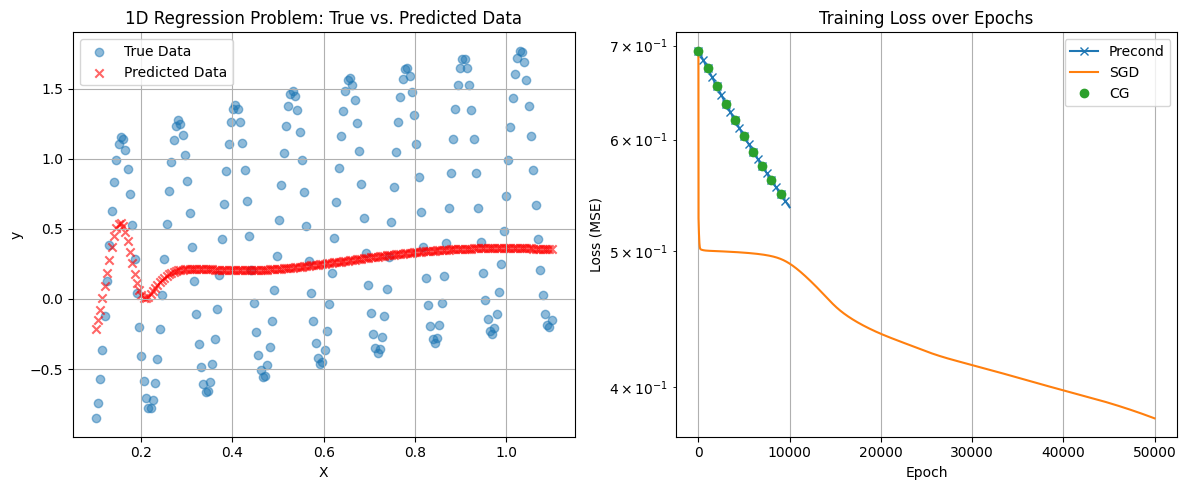

In [80]:
predicted_y = model.apply({'params': trained_state_precond_cg.params}, X)

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# First subplot for True vs. Predicted Data
plt.subplot(1, 2, 1)  # 2 rows, 1 column, 1st subplot
plt.scatter(X[:, 0], y[:, 0], marker='o', label='True Data', alpha=0.5)
plt.scatter(X[:, 0], predicted_y[:, 0], marker='x', color='red', label='Predicted Data', alpha=0.6)
plt.title('1D Regression Problem: True vs. Predicted Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Second subplot for Training Loss over Epochs
plt.subplot(1, 2, 2)  # 2 rows, 1 column, 2nd subplot
plt.semilogy(precond_losses, 'x-', label='Precond', markevery=500)
plt.semilogy(sgd_losses, label='SGD')
plt.semilogy(precond_losses_cg, 'o', label='CG', markevery=1000)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Show the combined plot
plt.tight_layout()  
plt.show()

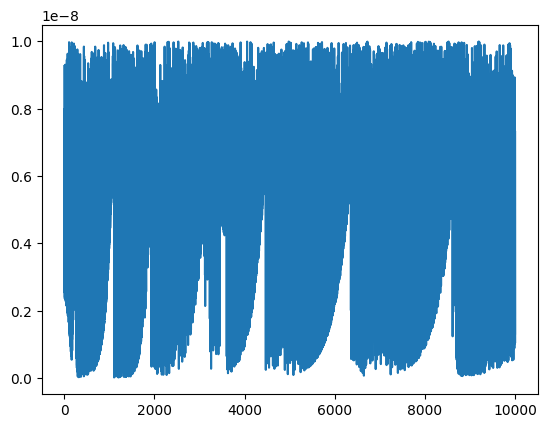

[<matplotlib.lines.Line2D at 0x7fc9ad025810>]

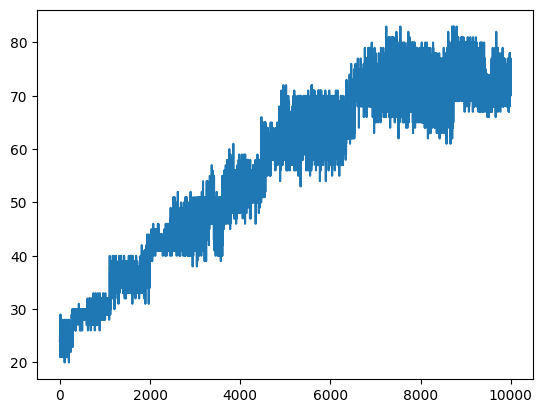

In [67]:
plt.plot(cg_stats['resids'])
plt.show()
plt.plot(cg_stats['iters'])